# Using the Groq API in Google Colab

Setup for fast LLM inference using Groq.

## 1. Get your API key
**Step 1.** Go to [console.groq.com](https://console.groq.com) and sign in (Google/GitHub works or you can just give your email & it will send you an one time sign-in link).

Free tier is generous for testing, no card needed to start.
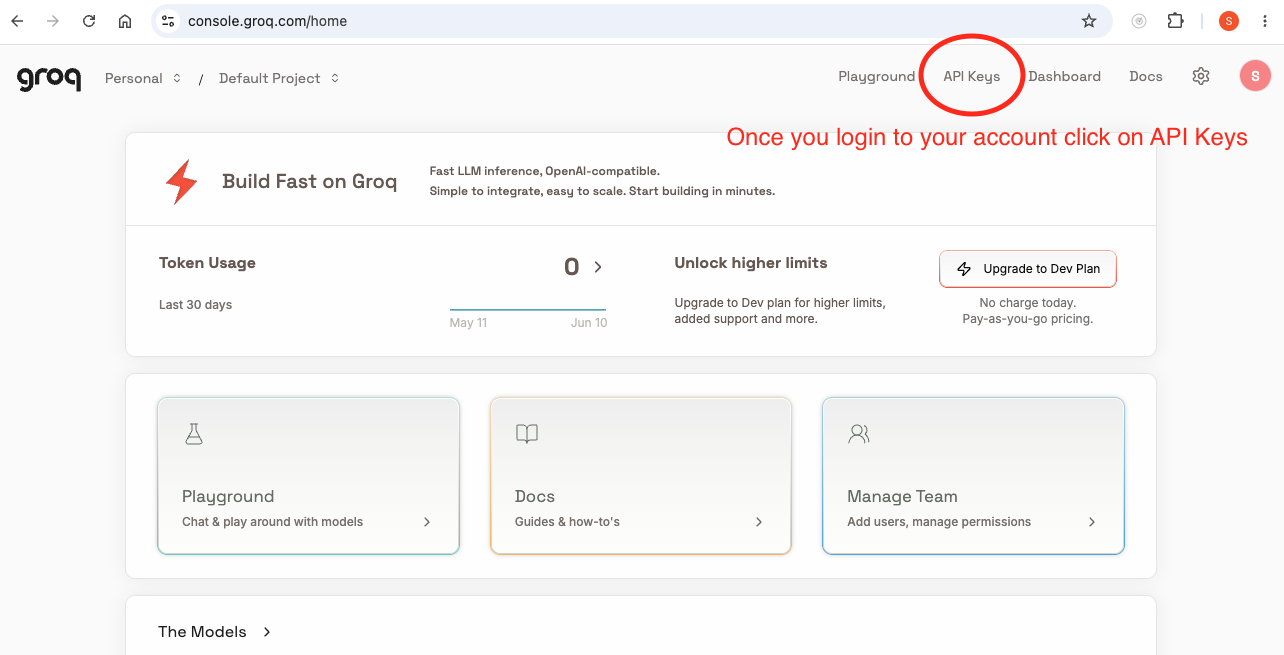




**Step 2.** Once you are logged-in, in the left sidebar, click **API Keys**.


**Step 3.** Click **Create API Key**, name it, and copy it immediately. You won't see it again after closing the dialog.

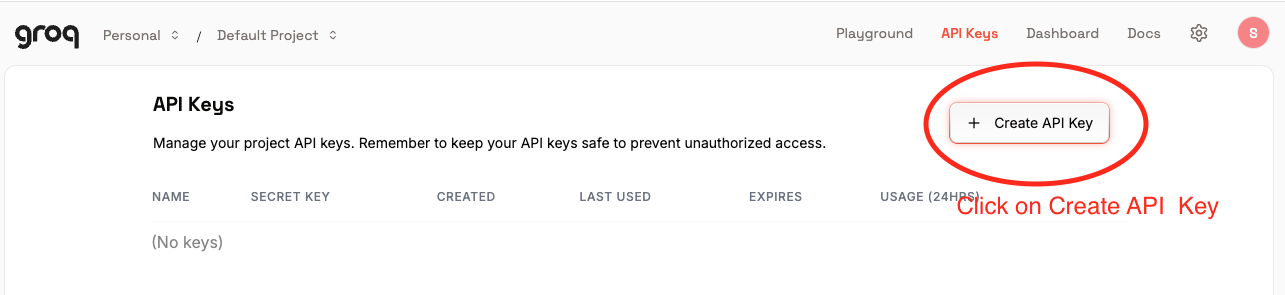

**Step 4:** You will get a pop-up box where you can enter a display name for your API key and set an expiration date. Click **Submit**

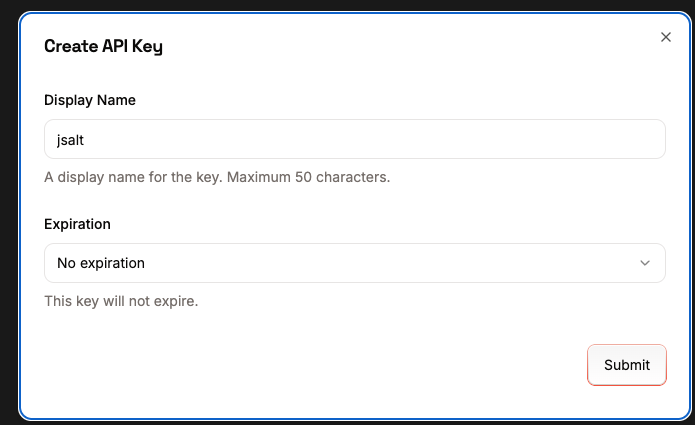

**Step 5:** Copy the API key using the copy button and then you can paste this either the Colab Input box in *Option A* or in Colab secrets *Option B.* Note that you would need to store this in your notes or yur favorite place to keep passwords because you will not see this key again

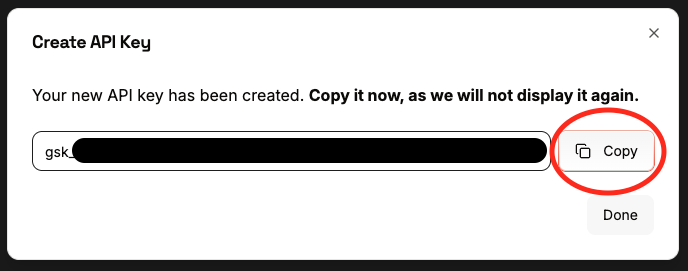

## 2. Install the SDK

In [2]:
!pip install -q groq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.7/143.7 kB 8.4 MB/s eta 0:00:00


## 3. Set the key (run ONE of the two cells below)

**Option A — getpass.** Quick, no setup. Key lives only in this runtime's memory. Good for a one-off.

In [5]:
import os
from getpass import getpass

os.environ["GROQ_API_KEY"] = getpass("Enter your Groq API key: ")

Enter your Groq API key: ··········


**Option B — Colab Secrets.** Cleaner and reusable. Set it once, never paste again.

1. Click the key icon in Colab's left sidebar.
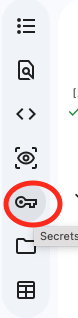
2. Add a secret named exactly `GROQ_API_KEY`, paste your key as the value.
3. Toggle **Notebook access** on, then run the cell below.

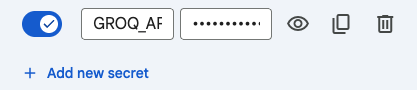

In [10]:
import os
from google.colab import userdata

os.environ["GROQ_API_KEY"] = userdata.get("GROQ_API_KEY")

## 4. Make your first call

In [7]:
from groq import Groq

client = Groq()  # reads GROQ_API_KEY from the environment automatically

response = client.chat.completions.create(
    model="llama-3.3-70b-versatile",
    messages=[
        {"role": "system", "content": "You are a concise assistant."},
        {"role": "user", "content": "Explain why Groq's inference is fast in 3 sentences."},
    ],
)

print(response.choices[0].message.content)

Groq's inference is fast due to its specialized Tensor Parallel architecture, which enables efficient processing of large models. This architecture allows for the distribution of model weights and computations across multiple processing units, reducing communication overhead and increasing overall throughput. Additionally, Groq's compiler and software stack are optimized for inference workloads, further accelerating performance and making it a competitive solution for large-scale AI deployments.


## 5. Stream the response (optional, feels faster)

In [8]:
stream = client.chat.completions.create(
    model="llama-3.3-70b-versatile",
    messages=[{"role": "user", "content": "Give me 5 ideas for a weekend project."}],
    stream=True,
)

for chunk in stream:
    print(chunk.choices[0].delta.content or "", end="")

Here are 5 ideas for a weekend project:

1. **Build a DIY Planter Box**: Create a beautiful planter box for your garden or backyard using wooden planks, screws, and a hammer. You can add a personal touch by painting or staining the box with your favorite colors. This project can be completed in a few hours and will add a lovely touch to your outdoor space.

2. **Organize Your Closet**: Spend the weekend organizing your closet by sorting through your clothes, shoes, and accessories. You can install shelves, hooks, and rods to maximize storage space. This project will not only make your closet look more organized, but it will also help you get rid of clothes you no longer wear.

3. **Create a Photo Album or Scrapbook**: Gather your favorite photos and create a beautiful photo album or scrapbook. You can add captions, stickers, and other embellishments to make it more personalized. This project is a great way to relive memories and create a keepsake that you can treasure for years to come

## Notes on models
- `llama-3.3-70b-versatile` is a solid current default.
- For stronger reasoning, swap in `openai/gpt-oss-120b`.
- Groq deprecates models often. If a call fails with an invalid-model error, run `client.models.list()` to see what's live and update the string.

